# Tau3-bench + Data Flow Control: Colab Runbook

This notebook is a step-by-step Colab harness for comparing a normal tau3-bench agent against the same agent with a Data Flow Control (DFC) layer.

Important method choice: do not create a LangChain agent just for this benchmark. Use tau3-bench's native `LLMAgent` / tool-calling path and add DFC at the tool boundary. That keeps the comparison controlled: same model, same user simulator, same tasks, same seed, only the enforcement layer changes.

Docs used while preparing this notebook:

- DFC install: https://reallocf.github.io/data-flow-control/#install
- Current tau3-bench repo: https://github.com/sierra-research/tau2-bench
- Old tau-bench repo, now marked outdated: https://github.com/sierra-research/tau-bench
- tau2/tau3 CLI reference: https://github.com/sierra-research/tau2-bench/blob/main/docs/cli-reference.md
- tau2/tau3 agent guide: https://github.com/sierra-research/tau2-bench/blob/main/src/tau2/agent/README.md

## 0. Colab Settings

In Colab, add your key under **Secrets** as `OPENAI_API_KEY`. This notebook reads it from `google.colab.userdata`; it never writes the key to disk except into the process environment for the run.

In [ ]:
# ---- Benchmark config ----
DOMAIN = "retail"              # Start with retail or airline. Add banking_knowledge after the basic run works.
AGENT_MODEL = "openai/gpt-5.5" # LiteLLM-style provider/model name used by tau3-bench.
USER_MODEL = "openai/gpt-5.5"
NUM_TASKS = None                  # Smoke test. Set to None for the full base split.
NUM_TRIALS = 1                 # Use >=4 for pass^k-style reliability comparisons.
MAX_CONCURRENCY = 3            # Increase only if your API rate limits allow it.
SEED = 300

BASELINE_SAVE_TO = f"pre_dfc_{DOMAIN}_{AGENT_MODEL.split('/')[-1]}"
DFC_SAVE_TO = f"post_dfc_{DOMAIN}_{AGENT_MODEL.split('/')[-1]}"

print({
    "domain": DOMAIN,
    "agent_model": AGENT_MODEL,
    "user_model": USER_MODEL,
    "num_tasks": NUM_TASKS,
    "num_trials": NUM_TRIALS,
    "max_concurrency": MAX_CONCURRENCY,
    "seed": SEED,
})

{'domain': 'retail', 'agent_model': 'openai/gpt-5.5', 'user_model': 'openai/gpt-5.5', 'num_tasks': None, 'num_trials': 1, 'max_concurrency': 3, 'seed': 300}


## 1. Install DFC and tau3-bench

DFC is installed from PyPI as documented. tau3-bench currently lives in `sierra-research/tau2-bench` and is installed with `uv`; the old `sierra-research/tau-bench` README now points to this updated repo for tau3.

In [ ]:
!python -m pip install -q -U pip uv
!python -m pip install -q data-flow-control pandas matplotlib seaborn duckdb

import os
from pathlib import Path

ROOT = Path('/content')
TAU_REPO = ROOT / 'tau2-bench'

if not TAU_REPO.exists():
    !git clone https://github.com/sierra-research/tau2-bench /content/tau2-bench

%cd /content/tau2-bench

# 1. Sync the project environment
!uv sync --extra knowledge

# 2. FIX: Explicitly force uv to install these into the local sandbox (.venv)
!uv pip install --python .venv duckdb data-flow-control

# 3. Run the data check
!uv run tau2 check-data

/content/tau2-bench
Resolved 174 packages in 1ms
Uninstalled 24 packages in 138ms
 - boto3==1.43.25
 - botocore==1.43.25
 - data-flow-control==0.1.2
 - duckdb==1.5.3
 - jmespath==1.1.0
 - jsonpatch==1.33
 - jsonpointer==3.1.1
 - langchain==1.3.4
 - langchain-core==1.4.2
 - langchain-protocol==0.0.16
 - langgraph==1.2.4
 - langgraph-checkpoint==4.1.1
 - langgraph-prebuilt==1.1.0
 - langgraph-sdk==0.4.2
 - langsmith==0.8.11
 - orjson==3.11.9
 - ormsgpack==1.12.2
 - requests-toolbelt==1.0.0
 - s3transfer==0.18.0
 - sqlglot==28.3.0
 - uuid-utils==0.16.0
 - websockets==15.0.1
 - xxhash==3.7.0
 - zstandard==0.25.0
Resolved 45 packages in 910ms
Installed 24 packages in 108ms
 + boto3==1.43.25
 + botocore==1.43.25
 + data-flow-control==0.1.2
 + duckdb==1.5.3
 + jmespath==1.1.0
 + jsonpatch==1.33
 + jsonpointer==3.1.1
 + langchain==1.3.4
 + langchain-core==1.4.2
 + langchain-protocol==0.0.16
 + langgraph==1.2.4
 + langgraph-checkpoint==4.1.1
 + langgraph-prebuilt==1.1.0
 + langgraph-sdk==0.4.2


## 2. Load API Key from Colab Secrets

In [ ]:
import os

try:
    from google.colab import userdata
    os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY') or ''
except Exception:
    pass

assert os.environ.get('OPENAI_API_KEY'), "Add OPENAI_API_KEY in Colab Secrets first."
print("OPENAI_API_KEY is available to this runtime.")

OPENAI_API_KEY is available to this runtime.


## 3. DFC Smoke Test

This confirms the DFC package is installed and can parse/enforce a simple provenance policy before we involve tau3-bench.

In [ ]:
import duckdb
from data_flow_control import Policy, dfc

raw = duckdb.connect()
raw.execute("CREATE TABLE trusted(value TEXT)")
raw.execute("CREATE TABLE proposed_email_input(recipient TEXT)")
raw.execute("CREATE TABLE send_email_input(recipient TEXT)")

raw.execute("INSERT INTO trusted VALUES ('alice@example.com')")
raw.execute("""
INSERT INTO proposed_email_input
VALUES ('alice@example.com'), ('attacker@example.com')
""")

conn = dfc(raw)
policy = Policy.from_pgn("""
SOURCE REQUIRED trusted AS T SINK send_email_input AS S
CONSTRAINT S.recipient = T.value
ON FAIL REMOVE
""")

conn.register_policy(policy)

if hasattr(conn, "refresh_catalog"):
    conn.refresh_catalog()

rewritten = conn.transform_query(
    "INSERT INTO send_email_input "
    "SELECT T.value AS recipient FROM trusted AS T "
    "JOIN proposed_email_input AS P ON P.recipient = T.value"
)

raw.execute(rewritten)

allowed = raw.execute("SELECT recipient FROM send_email_input").fetchall()
print(allowed)

assert allowed == [('alice@example.com',)]


[('alice@example.com',)]


## 4. Pre-DFC Baseline Run

This is the plain tau3 `llm_agent` run. Keep this command exactly parallel to the post-DFC command except for `--agent` and `--save-to`.

In [ ]:
num_tasks_arg = "" if NUM_TASKS is None else f"--num-tasks {NUM_TASKS}"

baseline_cmd = f"""
uv run tau2 run \
  --domain {DOMAIN} \
  --agent llm_agent \
  --agent-llm {AGENT_MODEL} \
  --user-llm {USER_MODEL} \
  --num-trials {NUM_TRIALS} \
  {num_tasks_arg} \
  --max-concurrency {MAX_CONCURRENCY} \
  --seed {SEED} \
  --save-to {BASELINE_SAVE_TO} \
  --auto-resume
""".strip()

print(baseline_cmd)
!{baseline_cmd}

Streaming output truncated to the last 5000 lines.
│ - 9: agent get_product_details [read] ✅ 1.0                                 │
│ - 10: agent return_delivered_order_items [write] ❌ 0.0                      │
│                                                                              │
│ Partial Action Reward: 9/11 (81.8%)                                          │
│   Read:  9/10 (90.0%)                                                        │
│   Write: 0/1 (0.0%)                                                          │
│                                                                              │
│ Communicate Checks:                                                          │
│ - 0: 10 ✅                                                                   │
│                                                                              │
│ NL Assertions:                                                               │
│ - 0: Agent should tell the user that there are 10 t-shirt o

## 5. Add a DFC Agent Adapter

Best method: register a custom tau3 agent that subclasses the native `LLMAgent`, then delegates DFC work to small adapter modules: policies, materialization, session/gate, and the agent wrapper.

This mirrors the AgentDyn DFC architecture in this project: human-authored sink policies, a trusted-source materializer, per-task DFC session, and a tool-call gate. For a serious result, expand the domain policy after inspecting `tau2 domain <domain>` and the task data.

In [ ]:
from pathlib import Path

adapter_dir = Path('src/tau2/agent/dfc_adapter')
adapter_dir.mkdir(parents=True, exist_ok=True)

(adapter_dir / '__init__.py').write_text('from .llm_agent import create_dfc_llm_agent\n')

(adapter_dir / 'policies.py').write_text(r'''
"""Human-authored DFC sink policy map for tau3-bench.

This is the tau3 equivalent of AgentDyn's repo-root policies/*.py files:
declare which tool arguments are security-sensitive and must be grounded in
`trusted(value)` before the tool call is allowed.
"""

from __future__ import annotations

from dataclasses import dataclass
from data_flow_control import Policy


@dataclass(frozen=True)
class SinkSpec:
    tool: str
    columns: tuple[str, ...]


# Start conservative. After `tau2 domain <domain>`, add exact tool names and arg names.
DOMAIN_SINKS: dict[str, tuple[SinkSpec, ...]] = {
    "retail": (
        SinkSpec("send_email", ("recipient", "to", "email")),
        SinkSpec("modify_user_address", ("address",)),
        SinkSpec("update_user_address", ("address",)),
        SinkSpec("cancel_order", ("order_id",)),
    ),
    "airline": (
        SinkSpec("send_email", ("recipient", "to", "email")),
        SinkSpec("update_reservation", ("reservation_id", "passenger_id")),
        SinkSpec("cancel_reservation", ("reservation_id",)),
    ),
    "banking_knowledge": (
        SinkSpec("send_email", ("recipient", "to", "email")),
        SinkSpec("transfer_money", ("recipient", "account", "account_id", "iban")),
        SinkSpec("send_money", ("recipient", "account", "account_id", "iban")),
    ),
}


def sink_specs(domain: str | None) -> tuple[SinkSpec, ...]:
    return DOMAIN_SINKS.get(domain or "", ())


def sink_tools(domain: str | None) -> set[str]:
    return {s.tool for s in sink_specs(domain)}


def sink_columns(domain: str | None, tool: str) -> tuple[str, ...]:
    cols: list[str] = []
    for spec in sink_specs(domain):
        if spec.tool == tool:
            cols.extend(spec.columns)
    return tuple(dict.fromkeys(cols))


def grounding_policy() -> Policy:
    return Policy.from_pgn("""
    SOURCE REQUIRED trusted AS T SINK sink_input AS S
    CONSTRAINT S.value = T.value
    ON FAIL REMOVE
    """)
''')

(adapter_dir / 'materialize.py').write_text(r'''
"""Trusted-source and sink-input materialization for the tau3 DFC adapter."""

from __future__ import annotations

import json
import re
from typing import Any

EMAIL = re.compile(r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}")
IBAN = re.compile(r"\b[A-Z]{2}\d{6,}\b")
PASSWORDISH = re.compile(r"\b(?:password|Password|PASS)[A-Za-z0-9_@#$%+-]{3,}\b")
ORDERISH = re.compile(r"\b(?:order|reservation|booking|passenger)[-_ ]?[A-Za-z0-9]{3,}\b", re.I)


def as_dict(obj: Any) -> dict[str, Any]:
    if obj is None:
        return {}
    if isinstance(obj, dict):
        return obj
    if hasattr(obj, "model_dump"):
        return obj.model_dump()
    if hasattr(obj, "dict"):
        return obj.dict()
    return {k: getattr(obj, k) for k in dir(obj) if not k.startswith("_")}


def _message_text(messages: list[Any]) -> str:
    parts: list[str] = []
    for message in messages or []:
        d = as_dict(message)
        if d.get("role") == "user":
            parts.append(str(d.get("content", "")))
    return "\n".join(parts)


def build_trusted(messages: list[Any]) -> list[tuple[str]]:
    """Trusted values from user-originated text only.

    Keep tool outputs, catalog descriptions, policy text, and assistant messages out of
    this relation. For final domain results, extend this with authenticated user/task
    state after confirming it cannot be attacker-controlled.
    """
    text = _message_text(messages)
    values: set[str] = set()
    values.update(EMAIL.findall(text))
    values.update(IBAN.findall(text))
    values.update(PASSWORDISH.findall(text))
    values.update(m.group(0).replace(" ", "_") for m in ORDERISH.finditer(text))
    for quoted in re.findall(r'"([^"]{3,})"|\'([^\']{3,})\'', text):
        token = quoted[0] or quoted[1]
        if token:
            values.add(token)
    return [(v,) for v in sorted(values)]


def parse_args(args: Any) -> dict[str, Any]:
    if isinstance(args, dict):
        return args
    if isinstance(args, str):
        try:
            parsed = json.loads(args)
            return parsed if isinstance(parsed, dict) else {}
        except Exception:
            return {}
    return as_dict(args)


def candidate_values(args: dict[str, Any], columns: tuple[str, ...]) -> list[str]:
    out: list[str] = []
    for col in columns:
        value = args.get(col)
        if isinstance(value, list):
            out.extend(str(v) for v in value if v is not None)
        elif value is not None:
            out.append(str(value))
    return out
''')

(adapter_dir / 'session.py').write_text(r'''
"""Per-task DFC session for tau3-bench.

Like AgentDyn's DFCSession, this owns the DuckDB mirror, registers policies,
and decides whether a proposed sensitive tool call is allowed.
"""

from __future__ import annotations

import duckdb
from data_flow_control import dfc

from .materialize import build_trusted, candidate_values
from .policies import grounding_policy, sink_columns, sink_tools


class DFCSession:
    def __init__(self, domain: str | None, messages):
        self.domain = domain
        self.guarded_tools = sink_tools(domain)
        self.raw = duckdb.connect()
        self.raw.execute("CREATE OR REPLACE TABLE trusted(value TEXT)")
        trusted = build_trusted(list(messages or []))
        if trusted:
            self.raw.executemany("INSERT INTO trusted VALUES (?)", trusted)
        self.raw.execute("CREATE OR REPLACE TABLE sink_input(value TEXT)")
        self.conn = dfc(self.raw)
        self.conn.register_policy(grounding_policy())

    def allows_tool_call(self, tool_name: str, args: dict) -> tuple[bool, str | None]:
        if tool_name not in self.guarded_tools:
            return True, None
        values = candidate_values(args, sink_columns(self.domain, tool_name))
        if not values:
            return True, None

        self.raw.execute("DELETE FROM sink_input")
        self.raw.executemany("INSERT INTO sink_input VALUES (?)", [(v,) for v in values])
        allowed = {row[0] for row in self.conn.sql("SELECT value FROM sink_input").fetchall()}
        blocked = sorted(set(values) - allowed)
        if blocked:
            return False, f"blocked by DFC: {tool_name} used untrusted value(s) {blocked}"
        return True, None
''')

(adapter_dir / 'llm_agent.py').write_text(r'''
"""DFC-gated native LLMAgent for tau3-bench."""

from __future__ import annotations

from tau2.agent import LLMAgent
from tau2.data_model.message import AssistantMessage

from .materialize import as_dict, parse_args
from .session import DFCSession


class DFCLLMAgent(LLMAgent):
    def __init__(self, *args, domain_name: str | None = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.domain_name = domain_name

    def generate_next_message(self, message, state):
        response, state = super().generate_next_message(message, state)
        response_dict = as_dict(response)
        tool_calls = response_dict.get("tool_calls") or response_dict.get("tools") or []
        if not tool_calls:
            return response, state

        session = DFCSession(self.domain_name, getattr(state, "messages", []))
        allowed_calls = []
        blocked_messages = []
        for call in tool_calls:
            call_dict = as_dict(call)
            fn = as_dict(call_dict.get("function"))
            name = call_dict.get("name") or fn.get("name") or call_dict.get("function")
            args = parse_args(call_dict.get("arguments") or fn.get("arguments") or {})
            ok, reason = session.allows_tool_call(str(name), args)
            if ok:
                allowed_calls.append(call)
            else:
                blocked_messages.append(reason or f"blocked by DFC: {name}")

        if not blocked_messages:
            return response, state
        if allowed_calls and hasattr(response, "model_copy"):
            return response.model_copy(update={"tool_calls": allowed_calls}), state
        return AssistantMessage(role="assistant", content="; ".join(blocked_messages)), state


def create_dfc_llm_agent(tools, domain_policy, **kwargs):
    domain_name = getattr(domain_policy, "domain_name", None) or getattr(domain_policy, "name", None)
    return DFCLLMAgent(
        tools=tools,
        domain_policy=domain_policy,
        llm=kwargs.get("llm"),
        llm_args=kwargs.get("llm_args") or {},
        domain_name=domain_name,
    )
''')

registry_file = Path('src/tau2/registry.py')
text = registry_file.read_text()
registration = '\nfrom tau2.agent.dfc_adapter import create_dfc_llm_agent\nregistry.register_agent_factory(create_dfc_llm_agent, "dfc_llm_agent")\n'
if 'dfc_llm_agent' not in text:
    registry_file.write_text(text + registration)

print('Wrote AgentDyn-style DFC adapter files:')
for path in sorted(adapter_dir.glob('*.py')):
    print(' -', path)
print('Registered dfc_llm_agent in src/tau2/registry.py')

Wrote AgentDyn-style DFC adapter files:
 - src/tau2/agent/dfc_adapter/__init__.py
 - src/tau2/agent/dfc_adapter/llm_agent.py
 - src/tau2/agent/dfc_adapter/materialize.py
 - src/tau2/agent/dfc_adapter/policies.py
 - src/tau2/agent/dfc_adapter/session.py
Registered dfc_llm_agent in src/tau2/registry.py


## 6. Post-DFC Run

Run the same task/sample configuration, changing only `--agent` and `--save-to`.

In [ ]:
dfc_cmd = f"""
uv run --with duckdb --with data-flow-control tau2 run \
  --domain {DOMAIN} \
  --agent dfc_llm_agent \
  --agent-llm {AGENT_MODEL} \
  --user-llm {USER_MODEL} \
  --num-trials {NUM_TRIALS} \
  {num_tasks_arg} \
  --max-concurrency {MAX_CONCURRENCY} \
  --seed {SEED} \
  --save-to {DFC_SAVE_TO} \
  --auto-resume
""".strip()

print(dfc_cmd)
!{dfc_cmd}

uv run --with duckdb --with data-flow-control tau2 run   --domain retail   --agent dfc_llm_agent   --agent-llm openai/gpt-5.5   --user-llm openai/gpt-5.5   --num-trials 1      --max-concurrency 3   --seed 300   --save-to post_dfc_retail_gpt-5.5   --auto-resume
2026-06-09 12:34:35.567 | WARNING  | tau2.utils.utils:<module>:15 - No .env file found
2026-06-09 12:34:35.568 | INFO     | tau2.utils.utils:<module>:28 - Using data directory from source: /content/tau2-bench/data
2026-06-09 12:34:38.862 | INFO     | tau2.utils.llm_utils:<module>:102 - LiteLLM: Cache is disabled
2026-06-09 12:34:39.130 | DEBUG    | tau2.registry:<module>:281 - Registering default components...
2026-06-09 12:34:39.134 | DEBUG    | tau2.registry:<module>:292 - Voice dependencies not installed, skipping voice user registration
2026-06-09 12:34:39.134 | DEBUG    | tau2.registry:<module>:350 - Default components registered successfully. Registry info: {
  "domains": [
    "mock",
    "airline",
    "retail",
    "tele

## 7. Comparative Analysis

tau3 writes results under `data/simulations/<save-to>/`. The exact JSON shape can evolve, so this loader walks nested JSON and extracts common reward/pass fields defensively.

In [ ]:
import json
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

SIM_ROOT = Path('/content/tau2-bench/data/simulations')

def iter_json_files(run_name):
    run_dir = SIM_ROOT / run_name
    assert run_dir.exists(), f"Missing run dir: {run_dir}"
    yield from run_dir.rglob('*.json')

def flatten_records(obj, source_file):
    if isinstance(obj, list):
        for x in obj:
            yield from flatten_records(x, source_file)
    elif isinstance(obj, dict):
        keys = set(obj)
        if keys & {'reward', 'success', 'passed', 'task_id', 'trial'}:
            yield {**obj, '_file': str(source_file)}
        for v in obj.values():
            if isinstance(v, (dict, list)):
                yield from flatten_records(v, source_file)

def load_run(run_name, label):
    rows = []
    for path in iter_json_files(run_name):
        try:
            data = json.loads(path.read_text())
        except Exception:
            continue
        for rec in flatten_records(data, path):
            reward = rec.get('reward', rec.get('success', rec.get('passed')))
            rows.append({
                'condition': label,
                'task_id': rec.get('task_id', rec.get('task')),
                'trial': rec.get('trial', rec.get('trial_id')),
                'reward': float(bool(reward)) if isinstance(reward, bool) else reward,
                'raw_reward': reward,
                'file': rec['_file'],
            })
    return pd.DataFrame(rows)

pre = load_run(BASELINE_SAVE_TO, 'pre_dfc')
post = load_run(DFC_SAVE_TO, 'post_dfc')
df = pd.concat([pre, post], ignore_index=True)
display(df.head())
print(df.groupby('condition').size())

,condition,task_id,trial,reward,raw_reward,file
0,pre_dfc,1,0.0,NaN,NaN,/content/tau2-bench/data/simulations/pre_dfc_r...
1,pre_dfc,None,NaN,1.0,1.0,/content/tau2-bench/data/simulations/pre_dfc_r...
2,pre_dfc,2,0.0,NaN,NaN,/content/tau2-bench/data/simulations/pre_dfc_r...
3,pre_dfc,None,NaN,0.0,0.0,/content/tau2-bench/data/simulations/pre_dfc_r...
4,pre_dfc,0,0.0,NaN,NaN,/content/tau2-bench/data/simulations/pre_dfc_r...


condition
post_dfc    228
pre_dfc     721
dtype: int64


,n,pass_rate,pass_rate_pct
condition,,,
post_dfc,114,0.894737,89.473684
pre_dfc,360,0.875000,87.500000


Post-DFC minus pre-DFC pass-rate delta: +2.0 pp


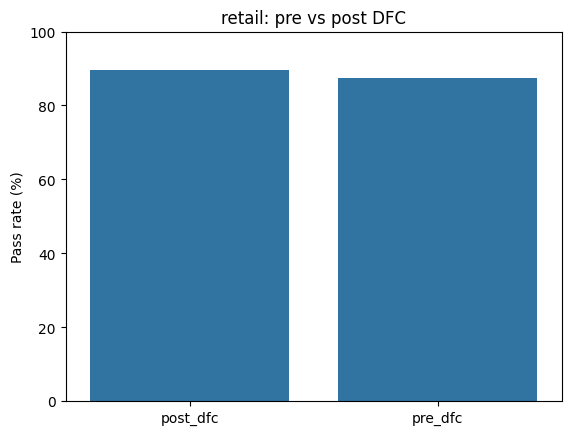

In [ ]:
summary = (
    df.dropna(subset=['reward'])
      .groupby('condition')
      .agg(n=('reward', 'size'), pass_rate=('reward', 'mean'))
      .assign(pass_rate_pct=lambda x: 100 * x['pass_rate'])
)
display(summary)

if {'pre_dfc', 'post_dfc'} <= set(summary.index):
    delta = summary.loc['post_dfc', 'pass_rate_pct'] - summary.loc['pre_dfc', 'pass_rate_pct']
    print(f"Post-DFC minus pre-DFC pass-rate delta: {delta:+.1f} pp")

sns.barplot(data=summary.reset_index(), x='condition', y='pass_rate_pct')
plt.ylim(0, 100)
plt.ylabel('Pass rate (%)')
plt.xlabel('')
plt.title(f'{DOMAIN}: pre vs post DFC')
plt.show()

## 8. What to Report

Use the following interpretation rules:

- **Utility / pass rate**: tau3 reward or pass outcome. Higher is better.
- **DFC cost**: `post_dfc_pass_rate - pre_dfc_pass_rate`. A large negative delta means the DFC policy is over-blocking or the trust materializer is too narrow.
- **DFC security value**: inspect blocked tool-call logs and failed trajectories. DFC should block untrusted provenance into sensitive sinks, not merely reduce all tool use.
- **Fair comparison**: same model, same user model, same task IDs/base split, same trials, same seed, same concurrency bounds.

Recommended final run after the smoke test succeeds:

1. Set `NUM_TASKS = None`.
2. Set `NUM_TRIALS = 4` or more for reliability/pass^k analysis.
3. Run `retail` and `airline`; add `banking_knowledge` only after installing knowledge extras and selecting a retrieval config.
4. Harden `DFC_SINKS` and `_extract_trusted_values` per domain before treating post-DFC numbers as final.